### Setup and Imports

In [441]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path

FIG_DIR = Path("..") / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")

PRIMARY_BLUE = "#1278cc"
LIGHT_BLUE = "#90CAF9"
ACCENT_ORANGE = "#FFA726"
ACCENT_RED = "#D32F2F"
TEXT_COLOR = "#1f2d3d"

palette = [ACCENT_RED, ACCENT_ORANGE, PRIMARY_BLUE, LIGHT_BLUE] 

plt.rcParams.update({
    "figure.figsize": (10, 5),
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

### Define Constants and Categories

In [442]:
VISIBILITY_BINS = [0, 1, 4, 9, 100]
VISIBILITY_LABELS = ["Fog", "Poor", "Moderate", "Good"]

VESSEL_TYPE_BINS = [-1,19,29,30,32,33,34,35,36,37,39,49,50,51,52,53,54,55,57,58,59,69,79,89,99]

VESSEL_TYPE_LABELS = [
    "Unknown","WIG","Fishing","Towing",
    "Dredging","Diving","Military","Sailing",
    "Pleasure Craft","Reserved","HSC","Pilot Vessel",
    "Search and Rescue","Tug","Port Tender",
    "Anti-pollution","Law Enforcement","Local Vessel",
    "Medical Transport","Noncombatant","Passenger",
    "Cargo","Tanker","Other"
]

### Loading Data

In [443]:
def load_data():
    ais = pd.read_parquet("../data/study_area/entrance.parquet")
    
    weather = pd.read_csv(
        "../data/weather_data/GHCNh_USW00012923_2022.psv",
        delimiter="|",
        parse_dates=["DATE"],
        usecols=["DATE", "visibility"]
    )
    
    return ais, weather

ais_df, weather_df = load_data()

### Preprocessing datasets

In [444]:
def preprocess_datasets(ais_df, weather_df):

    ais_df["Date_hour"] = ais_df["BaseDateTime"].dt.floor("h")
    ais_df["Date_month"] = ais_df["BaseDateTime"].dt.to_period("M").dt.start_time
    
    ais_df["VesselTypeName"] = pd.cut(
        ais_df["VesselType"],
        bins=VESSEL_TYPE_BINS,
        labels=VESSEL_TYPE_LABELS
    )
    weather_df["visibility_cat"] = pd.cut(
        weather_df["visibility"],
        bins=VISIBILITY_BINS,
        labels=VISIBILITY_LABELS
    )

    return ais_df, weather_df


ais_df, weather_df = preprocess_datasets(ais_df, weather_df)

### Data Integration (AIS + Weather)

In [445]:
merged_df = pd.merge_asof(
    ais_df.sort_values("BaseDateTime"),
    weather_df.sort_values("DATE"),
    left_on="BaseDateTime",
    right_on="DATE",
    direction="nearest",
    tolerance=pd.Timedelta("1h")
)

### Cleaning Merged Data

In [446]:
def clean_merged_data(merged_df):
    merged_df.drop_duplicates(subset=["MMSI", "BaseDateTime"])

    before = len(merged_df)
    merged_df = merged_df.dropna(subset=["SOG", "visibility"])
    
    print(f"Removed {before-len(merged_df)} rows")
    
    merged_df = merged_df[(merged_df["SOG"] > 0.5) & (merged_df["SOG"] < 30)]

    return merged_df

merged_df = clean_merged_data(merged_df)

Removed 271366 rows


### Exploring Weather Conditions

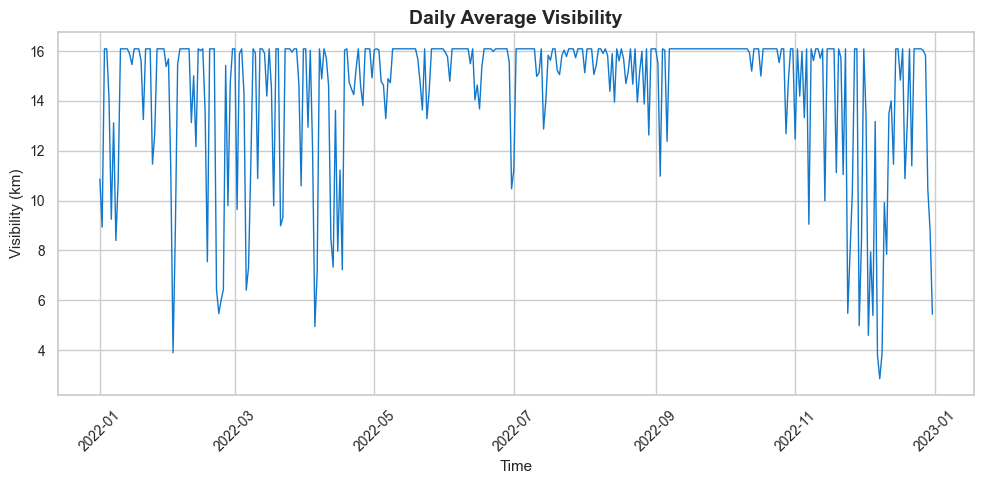

In [447]:
weather_df = weather_df[(weather_df["DATE"] > pd.to_datetime("2021-12-31")) & ((weather_df["DATE"] < pd.to_datetime("2023-01-01")))]
daily_weather_df = weather_df.resample("D", on="DATE")["visibility"].mean().reset_index()

plt.figure()
sns.lineplot(
    data=daily_weather_df,
    x="DATE",
    y="visibility",
    color=PRIMARY_BLUE,
    linewidth=1
)

plt.xlabel("Time")
plt.ylabel("Visibility (km)")
plt.title("Daily Average Visibility")

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIG_DIR / "daily_average_visibility.png", dpi=600, bbox_inches="tight")
plt.show()

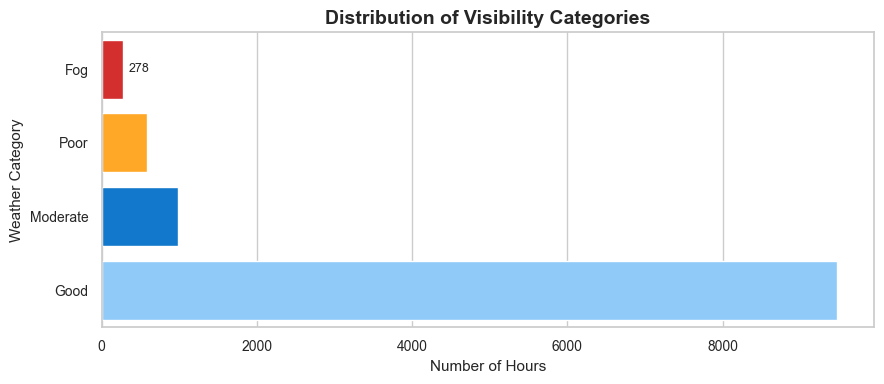

In [448]:
category_counts_df = weather_df.groupby("visibility_cat")["DATE"].count().reset_index(name="hour_count")
plt.figure(figsize=(9, 4))

ax = sns.barplot(
    data=category_counts_df,
    x="hour_count",
    y="visibility_cat",
    hue="visibility_cat",
    palette=palette,
    dodge=False,    
    legend=False,
    saturation=1 
)

ax.bar_label(ax.containers[0], fmt='%d', padding=4, fontsize=9)

plt.xlabel("Number of Hours")
plt.ylabel("Weather Category")
plt.title("Distribution of Visibility Categories")

plt.tight_layout()
plt.savefig(FIG_DIR / "visibility_distribution.png", dpi=600, bbox_inches="tight")
plt.show()

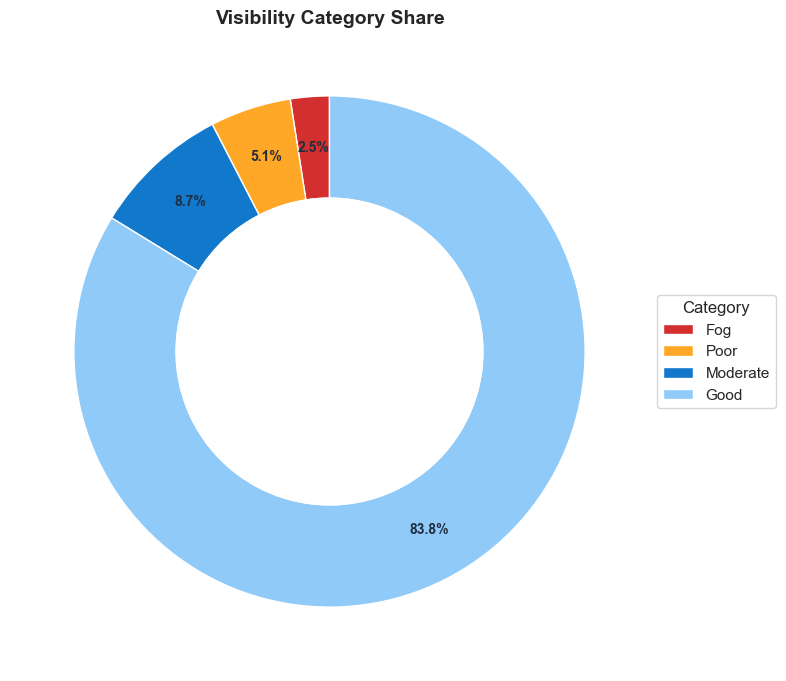

In [449]:
values = category_counts_df["hour_count"]
labels = category_counts_df["visibility_cat"]



plt.figure(figsize=(8, 8))

wedges, texts, autotexts = plt.pie(
    values,
    labels=None,
    autopct='%1.1f%%',
    startangle=90,
    colors=palette,
    wedgeprops=dict(width=0.4, edgecolor='white'),
    pctdistance=0.8
)

plt.legend(
    wedges,
    labels,
    title="Category",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

for autotext in autotexts:
    autotext.set_color(TEXT_COLOR)
    autotext.set_fontsize(10)
    autotext.set_weight('bold')

centre_circle = plt.Circle((0, 0), 0.6, fc='white')
plt.gca().add_artist(centre_circle)

plt.title("Visibility Category Share", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "visibility_share.png", dpi=600, bbox_inches="tight")
plt.show()

### Traffic Density Analysis

#### Definition
Traffic Density = Number of unique vessels per hour

In [450]:
density_hr_df = (
    merged_df.groupby(
    ["Date_hour", "visibility_cat"])["MMSI"]
    .nunique()
    .reset_index(name="vessel_count")
)

#### Average Density by Visibility

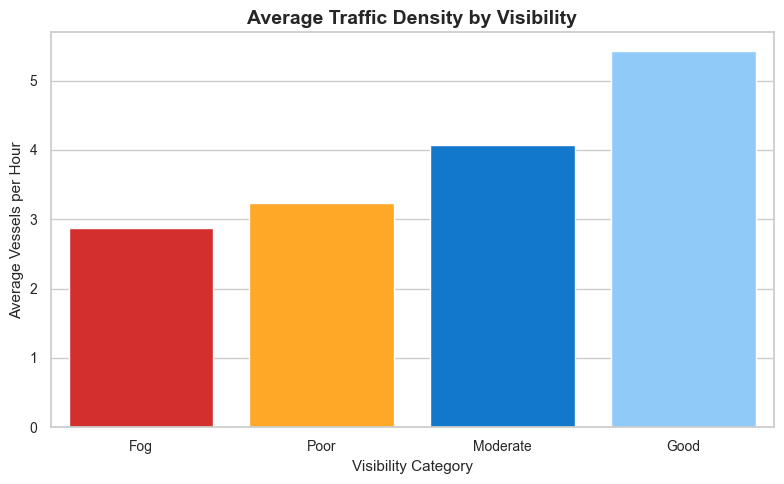

In [451]:
avg_density_df = (
    density_hr_df.groupby("visibility_cat")["vessel_count"]
    .mean().reset_index(name="avg_vessel_count")
)
plt.figure(figsize=(8, 5))

sns.barplot(
    data=avg_density_df,
    x="visibility_cat",
    y="avg_vessel_count",
    hue="visibility_cat",
    dodge=False,
    palette=palette,
    saturation=1
)

plt.xlabel("Visibility Category")
plt.ylabel("Average Vessels per Hour")
plt.title("Average Traffic Density by Visibility")

plt.tight_layout()
plt.savefig(FIG_DIR / "traffic_density_avg.png", dpi=600, bbox_inches="tight")
plt.show()

#### Density Distribution

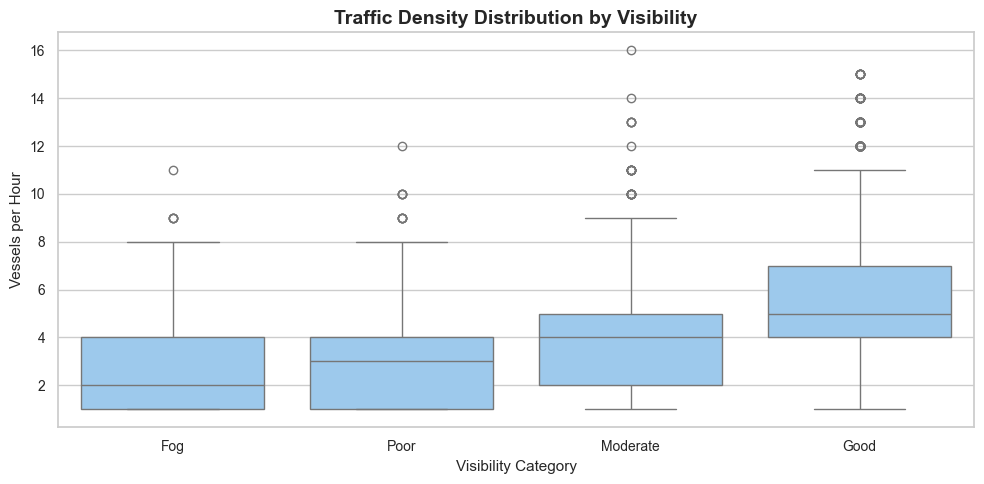

In [452]:
plt.figure()

sns.boxplot(
    data=density_hr_df,
    x="visibility_cat",
    y="vessel_count",
    color=LIGHT_BLUE
)

plt.title("Traffic Density Distribution by Visibility")
plt.xlabel("Visibility Category")
plt.ylabel("Vessels per Hour")

plt.tight_layout()
plt.savefig(FIG_DIR / "traffic_density_distribution.png", dpi=600, bbox_inches="tight")
plt.show()

#### Traffic Density Percentage Drop from Good to Fog 

In [453]:
visibility_values = avg_density_df.set_index("visibility_cat")["avg_vessel_count"]
good = visibility_values["Good"]
fog = visibility_values["Fog"]

percent_drop = ((good - fog) / good) * 100

print(f"Overall traffic density in Good visibility: {good:.2f} vessels")
print(f"Overall traffic density Fog:             {fog:.2f} vessels")
print(f"Traffic density drop from Good to Fog:      {percent_drop:.2f}%")

Overall traffic density in Good visibility: 5.43 vessels
Overall traffic density Fog:             2.87 vessels
Traffic density drop from Good to Fog:      47.05%


### Speed Analysis

#### Removing Outliers

In [454]:
def remove_outliers_vectorized(df, col, group_cols):
    q1 = df.groupby(group_cols)[col].transform(lambda x: x.quantile(0.25))
    q3 = df.groupby(group_cols)[col].transform(lambda x: x.quantile(0.75))
    iqr = q3 - q1
    return df[(df[col] >= q1 - 1.5 * iqr) & (df[col] <= q3 + 1.5 * iqr)]

clean_sog_df = remove_outliers_vectorized(merged_df, "SOG", group_cols=["MMSI", "visibility_cat"])

#### Mean Speed per Vessel per Visibility Category

In [455]:
# Minimum observation threshold
clean_sog_df = clean_sog_df.groupby(["MMSI", "visibility_cat"]).filter(lambda x: len(x) >= 5)

speed_df = (
    clean_sog_df.groupby(["MMSI", "visibility_cat"])
    .agg(
        SOG_mean=("SOG", "mean"),
        VesselTypeName=("VesselTypeName", "first")
    )
    .reset_index()
)

#### Average Speed by Visibility

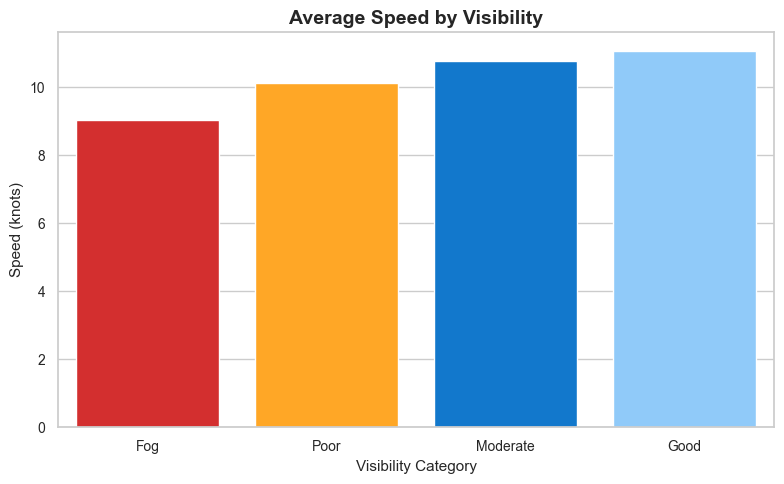

In [456]:
speed_vis = speed_df.groupby("visibility_cat")["SOG_mean"].mean().reset_index()

plt.figure(figsize=(8, 5))

sns.barplot(
    data=speed_vis,
    x="visibility_cat",
    y="SOG_mean",
    hue="visibility_cat",
    palette=palette,
    dodge=False,
    saturation=1
)

plt.title("Average Speed by Visibility")
plt.ylabel("Speed (knots)")
plt.xlabel("Visibility Category")

plt.tight_layout()
plt.savefig(FIG_DIR / "average_speed_visibility.png", dpi=600, bbox_inches="tight")
plt.show()

#### Overall Speed Drop from Good to Fog

In [457]:
speed_vis_indexed = speed_vis.set_index("visibility_cat")["SOG_mean"]
overall_good = speed_vis_indexed["Good"]
overall_fog = speed_vis_indexed["Fog"]
overall_percent_drop = ((overall_good - overall_fog)/overall_good)*100

print(f"Overall average speed in Good visibility: {overall_good:.2f} kn")
print(f"Overall average speed in Fog:             {overall_fog:.2f} kn")
print(f"Average speed drop from Good to Fog:      {overall_percent_drop:.2f}%")

Overall average speed in Good visibility: 11.06 kn
Overall average speed in Fog:             9.03 kn
Average speed drop from Good to Fog:      18.27%


#### Speed Decrease from Good to Fog per Vessel Type

In [458]:
good_fog_df = speed_df[speed_df["visibility_cat"].isin(["Good", "Fog"])]

speed_pivot = good_fog_df.groupby(["VesselTypeName", "visibility_cat"])["SOG_mean"].mean().unstack("visibility_cat")
speed_pivot = speed_pivot.dropna(subset=["Good", "Fog"])

speed_pivot["abs_decrease"] = speed_pivot["Good"] - speed_pivot["Fog"]
speed_pivot["pct_decrease"] = (speed_pivot["abs_decrease"] / speed_pivot["Good"]) * 100

speed_pivot = speed_pivot.reset_index().sort_values("abs_decrease", ascending=False)

print("\nTop 5 vessel types with greatest speed decrease from Good to Fog conditions:")
print(speed_pivot[["VesselTypeName", "Good", "Fog", "abs_decrease", "pct_decrease"]])



Top 5 vessel types with greatest speed decrease from Good to Fog conditions:
visibility_cat VesselTypeName       Good        Fog  abs_decrease  \
3                         Tug   5.766371   3.596429      2.169942   
7                      Tanker  10.848669   8.902153      1.946516   
2                Pilot Vessel  13.726197  12.137850      1.588347   
6                       Cargo  11.999702  10.703383      1.296319   
8                       Other   9.385254   8.140170      1.245085   
4                Local Vessel   5.991692   5.399107      0.592585   
5                   Passenger  12.647850  12.087661      0.560190   
1                      Towing   6.542699   7.028862     -0.486163   
0                     Unknown   9.543395  10.322569     -0.779174   

visibility_cat  pct_decrease  
3                  37.630986  
7                  17.942444  
2                  11.571648  
6                  10.802928  
8                  13.266391  
4                   9.890110  
5             

#### Top 5 Vessels Types by Speed Decrease

##### Good vs Fog

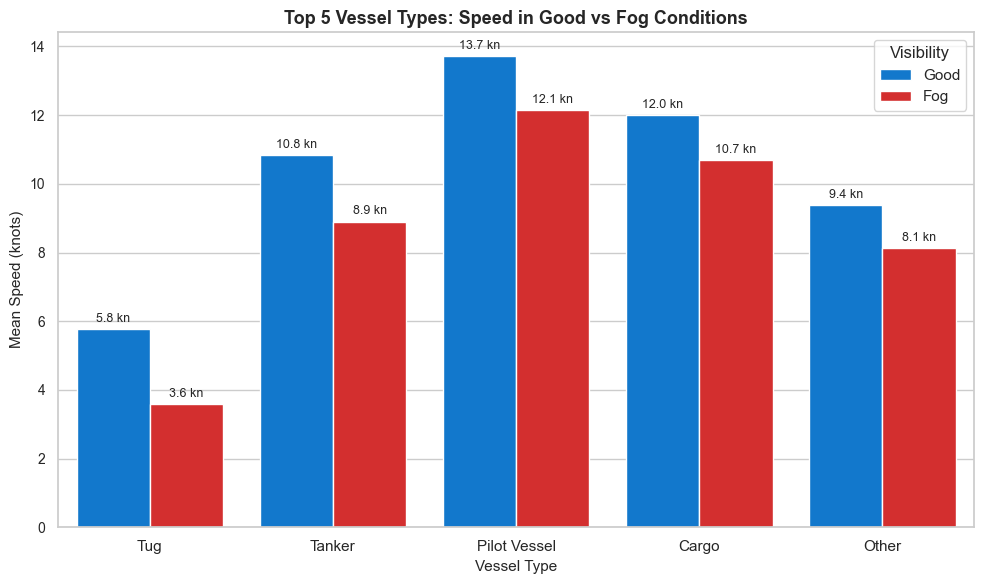

In [459]:
top5 = speed_pivot.head(5).copy()
top5["VesselTypeName"] = top5["VesselTypeName"].astype(str)

top5_melted = top5.melt(
    id_vars="VesselTypeName",
    value_vars=["Good", "Fog"],
    var_name="Visibility",
    value_name="SOG_mean"
)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=top5_melted,
    x="VesselTypeName",
    y="SOG_mean",
    hue="Visibility",
    palette={"Good": PRIMARY_BLUE, "Fog": ACCENT_RED},
    saturation=1
)

ax.set_title("Top 5 Vessel Types: Speed in Good vs Fog Conditions", fontsize=13)
ax.set_xlabel("Vessel Type")
ax.set_ylabel("Mean Speed (knots)")
ax.legend(title="Visibility")
ax.tick_params(axis="x", labelsize=11)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f kn", fontsize=9, padding=3)

plt.tight_layout()
plt.savefig(FIG_DIR / "top5_speed_good_vs_fog.png", dpi=600, bbox_inches="tight")
plt.show()

##### Percentage decrease

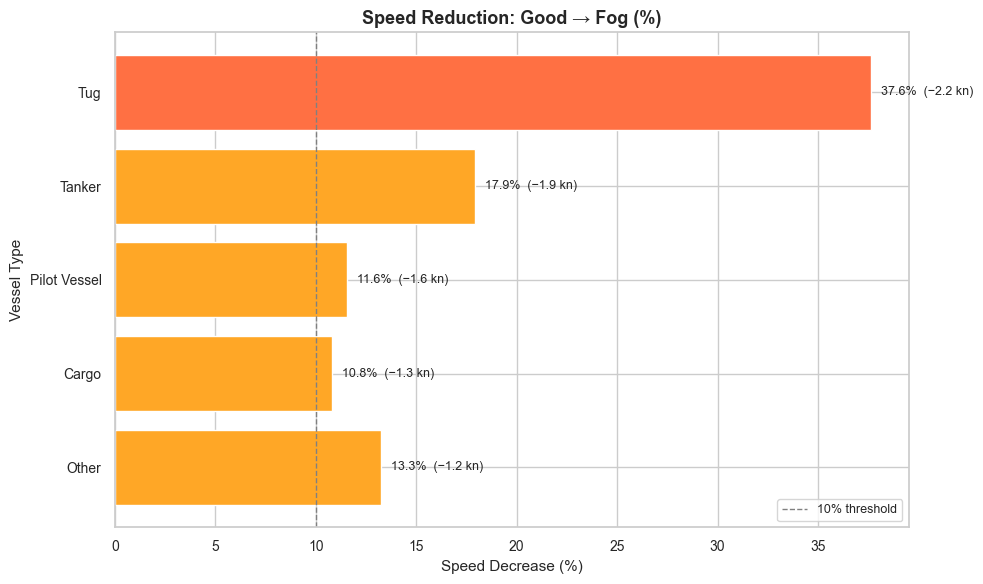

In [460]:
plt.figure(figsize=(10, 6))

colors = [
    "#D32F2F" if v >= 50 else "#FF7043" if v >= 25 else "#FFA726"
    for v in top5["pct_decrease"]
]

bars = plt.barh(
    top5["VesselTypeName"],
    top5["pct_decrease"],
    color=colors
)

plt.title("Speed Reduction: Good → Fog (%)", fontsize=13)
plt.xlabel("Speed Decrease (%)")
plt.ylabel("Vessel Type")
plt.gca().invert_yaxis()

for bar, (_, row) in zip(bars, top5.iterrows()):
    plt.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{row['pct_decrease']:.1f}%  (−{row['abs_decrease']:.1f} kn)",
        va="center", fontsize=9
    )

plt.axvline(x=10, color="grey", linestyle="--", linewidth=1, label="10% threshold")
plt.legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIG_DIR / "top5_speed_reduction.png", dpi=600, bbox_inches="tight")
plt.show()